# Safeguard playground

A sandbox for the statistical safeguard (`qmetrology/safeguard.py`) — the rule that turns a noisy
pilot estimate into the depth the exploitation measurement actually runs at. Change the pilot, the
budget or the precision target and watch the choice move.

Derivation and assumptions: [`docs/SAFEGUARD_DERIVATION.md`](../docs/SAFEGUARD_DERIVATION.md).


In [1]:
import os, sys
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import ndtr

ROOT = os.path.dirname(os.getcwd()) if os.path.basename(os.getcwd()) == "notebooks" else os.getcwd()
sys.path.insert(0, ROOT)

from qmetrology import manifest as M
from qmetrology.safeguard import _p_safe, _score, pilot_sd, risk_optimal_depth, effective_C
from qmetrology.trace import n_opt

plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False,
                     "axes.grid": True, "grid.alpha": 0.25, "legend.frameon": False})

scen = next(s for s in M.SCENARIOS if s["id"] == "narrow_e3")
PMIN, PMAX, EPS = scen["phi_min"], scen["phi_max"], scen["eps"]
N_MIN, N_MAX = M.n_min_of(scen), M.n_max_of(scen)
print(f"{scen['label']}   N in [{N_MIN}, {N_MAX}]")

U(0.01,0.1), eps=1e-03   N in [15, 157]


## The rule

Given a pilot `φ̂ₚ` measured at depth `Nₚ` with `mₚ` shots, its sd is `σₚ = 1/(2Nₚ√mₚ)` (assumption
A1: independent of φ). The safeguard enumerates **every** integer `N` in `[N_min, N_max]` and
maximises the product of two factors:

| factor | meaning |
|---|---|
| `p_safe(N)` | P(N does not alias) under the normal posterior for φ, truncated to `[φ_min, φ_max]` |
| `p_acc(N)`  | `2Φ(2εN√m) − 1` with `m = ⌊B/N⌋` — P(the estimate resolves ε), whole shots only |

`p_safe` falls with `N` (deeper is riskier), `p_acc` rises (deeper is sharper). The argmax is where
they cross; ties go to the smallest `N`.

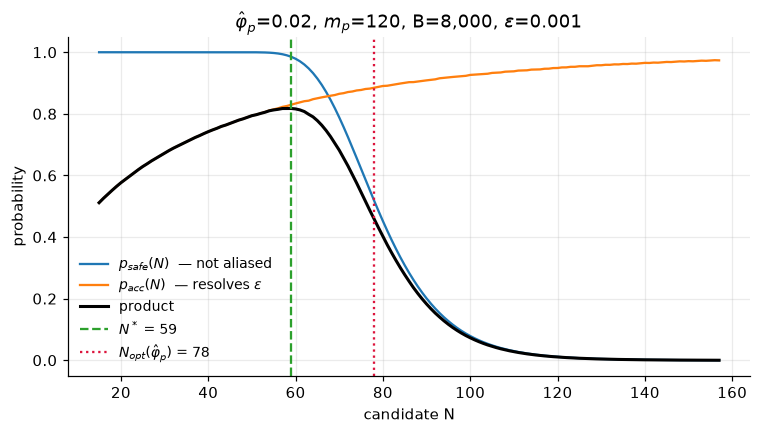

assumption A1 pilot sd = 3.04e-03   ->  N* = 59  (N_opt = 78)


In [2]:
def factors(phi_hat, sigma, budget, eps=EPS, N_min=N_MIN, N_max=N_MAX,
            support=(PMIN, PMAX)):
    N = np.arange(N_min, N_max + 1)
    m = int(budget) // N
    p_safe = _p_safe(N, phi_hat, sigma, support)
    p_acc = np.where(m >= 1, 2 * ndtr(2 * eps * N * np.sqrt(m)) - 1, 0.0)
    return N, p_safe, p_acc, p_safe * p_acc


phi_hat, m_pilot, B = 0.02, 120, 8_000
sigma = pilot_sd(N_MIN, m_pilot)
N, p_safe, p_acc, score = factors(phi_hat, sigma, B)
pick = risk_optimal_depth(phi_hat, sigma, B, EPS, N_min=N_MIN, N_max=N_MAX, support=(PMIN, PMAX))

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(N, p_safe, label=r"$p_{safe}(N)$  — not aliased")
ax.plot(N, p_acc, label=r"$p_{acc}(N)$  — resolves $\varepsilon$")
ax.plot(N, score, lw=2, color="k", label="product")
ax.axvline(pick, color="tab:green", ls="--", label=rf"$N^*$ = {pick}")
ax.axvline(n_opt(phi_hat), color="crimson", ls=":", label=rf"$N_{{opt}}(\hat\varphi_p)$ = {n_opt(phi_hat)}")
ax.set(xlabel="candidate N", ylabel="probability",
       title=rf"$\hat\varphi_p$={phi_hat}, $m_p$={m_pilot}, B={B:,}, $\varepsilon$={EPS:g}")
ax.legend(fontsize=9)
plt.show()
print(f"assumption A1 pilot sd = {sigma:.2e}   ->  N* = {pick}  (N_opt = {n_opt(phi_hat)})")

## Knob 1 — how sharp is the pilot?

More pilot shots means a tighter posterior, so the safeguard can afford to go deeper before
`p_safe` collapses. This is the whole reason binary search feeds it the *deepest accepted* probe
rather than the opening one: `σ` shrinks by exactly `N_acc/N_min`.

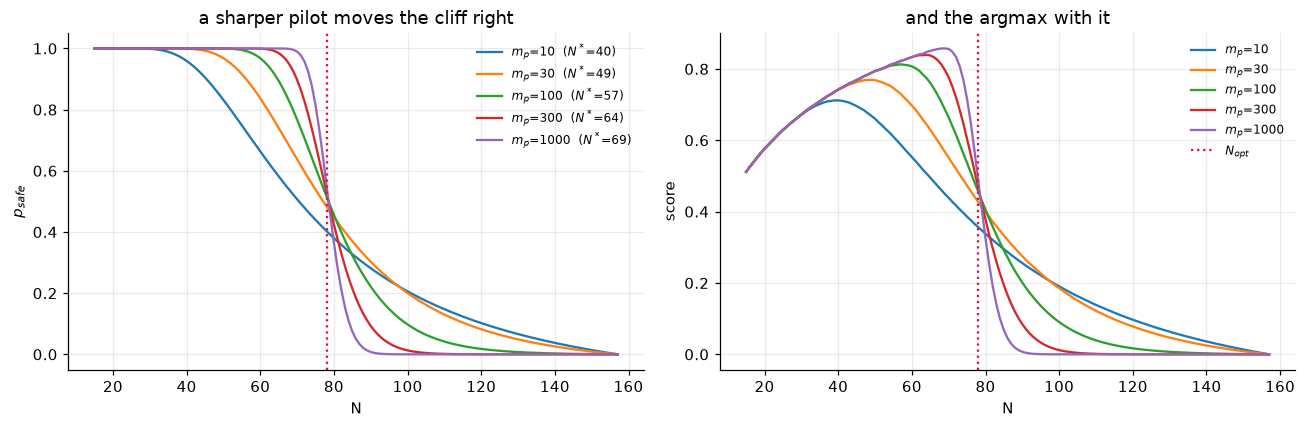

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for m_p in [10, 30, 100, 300, 1000]:
    s = pilot_sd(N_MIN, m_p)
    N, ps, _pa, sc = factors(phi_hat, s, B)
    pick = risk_optimal_depth(phi_hat, s, B, EPS, N_min=N_MIN, N_max=N_MAX, support=(PMIN, PMAX))
    axes[0].plot(N, ps, label=rf"$m_p$={m_p}  ($N^*$={pick})")
    axes[1].plot(N, sc, label=rf"$m_p$={m_p}")
axes[0].axvline(n_opt(phi_hat), color="crimson", ls=":")
axes[0].set(xlabel="N", ylabel=r"$p_{safe}$", title="a sharper pilot moves the cliff right")
axes[1].axvline(n_opt(phi_hat), color="crimson", ls=":", label=r"$N_{opt}$")
axes[1].set(xlabel="N", ylabel="score", title="and the argmax with it")
for a in axes:
    a.legend(fontsize=8)
plt.tight_layout(); plt.show()

## Knob 2 — the budget

`p_acc` uses **whole** shots, `m = ⌊B/N⌋`. At small budgets that floor bites: past `B/N < 1` no
candidate is affordable at all and the score is identically zero. The steps in the curve below are
the floor, not noise.

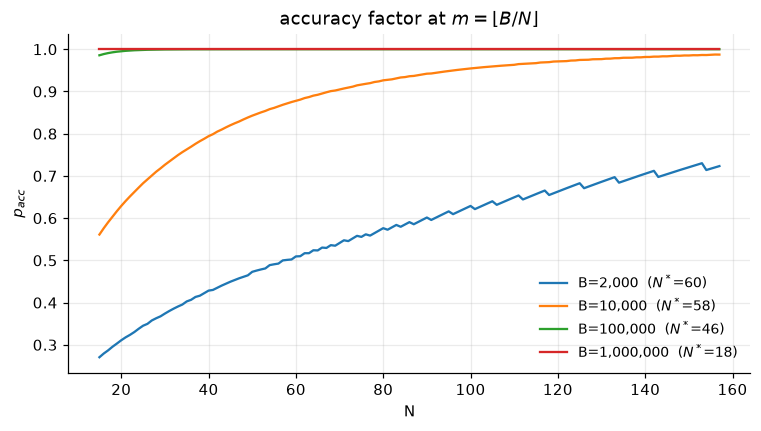

In [4]:
fig, ax = plt.subplots(figsize=(8, 4))
for B_try in [2_000, 10_000, 100_000, 1_000_000]:
    N, _ps, pa, _sc = factors(phi_hat, sigma, B_try)
    pick = risk_optimal_depth(phi_hat, sigma, B_try, EPS, N_min=N_MIN, N_max=N_MAX,
                              support=(PMIN, PMAX))
    ax.plot(N, pa, label=rf"B={B_try:,}  ($N^*$={pick})")
ax.set(xlabel="N", ylabel=r"$p_{acc}$", title=r"accuracy factor at $m=\lfloor B/N \rfloor$")
ax.legend(fontsize=9)
plt.show()

## Knob 3 — where the pilot landed

Sweeping `φ̂ₚ` across the prior support traces the rule's whole response. `N*` tracks `N_opt(φ̂ₚ)`
but stays deliberately below it — the gap is the safety margin the tuned constants used to
approximate with a single number.

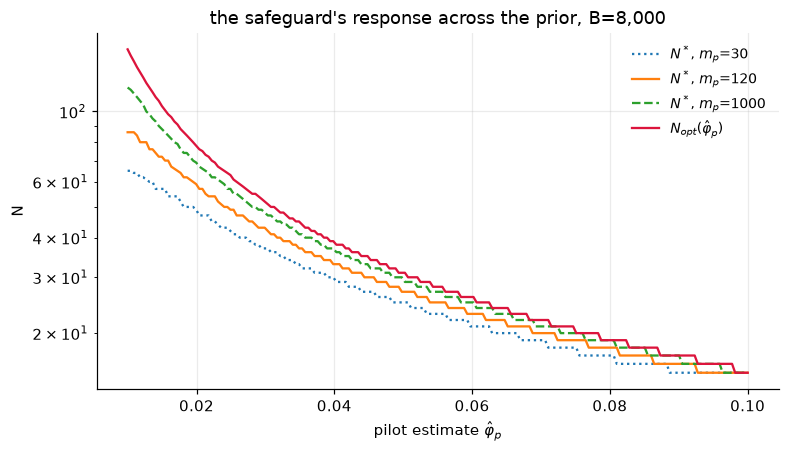

In [5]:
phis = np.linspace(PMIN, PMAX, 200)
fig, ax = plt.subplots(figsize=(8, 4.2))
for m_p, style in [(30, ":"), (120, "-"), (1000, "--")]:
    s = pilot_sd(N_MIN, m_p)
    picks = [risk_optimal_depth(p, s, B, EPS, N_min=N_MIN, N_max=N_MAX, support=(PMIN, PMAX))
             for p in phis]
    ax.plot(phis, picks, style, label=rf"$N^*$, $m_p$={m_p}")
ax.plot(phis, [n_opt(p) for p in phis], color="crimson", lw=1.5, label=r"$N_{opt}(\hat\varphi_p)$")
ax.set(xlabel=r"pilot estimate $\hat\varphi_p$", ylabel="N", yscale="log",
       title=rf"the safeguard's response across the prior, B={B:,}")
ax.legend(fontsize=9)
plt.show()

## What the tuned constant would have been

`effective_C` reports the safety factor `N*/N_opt(φ̂ₚ)` the rule implies — the number the published
algorithms fixed by grid search. It is *not* constant: it depends on how sharp the pilot is and how
much budget is left, which is exactly the dependence a single tuned constant cannot express.

In [6]:
print(f"{'phi_hat':>9} {'m_p':>6} {'B':>10} {'N*':>5} {'N_opt':>6} {'implied C':>10}")
for phi_p in (0.02, 0.05, 0.09):
    for m_p in (30, 300):
        for B_try in (10_000, 1_000_000):
            s = pilot_sd(N_MIN, m_p)
            Ns = risk_optimal_depth(phi_p, s, B_try, EPS, N_min=N_MIN, N_max=N_MAX,
                                    support=(PMIN, PMAX))
            C = effective_C(phi_p, s, B_try, EPS, N_min=N_MIN, N_max=N_MAX)
            print(f"{phi_p:9.3f} {m_p:6d} {B_try:10,} {Ns:5d} {n_opt(phi_p):6d} {C:10.3f}")

  phi_hat    m_p          B    N*  N_opt  implied C
    0.020     30     10,000    48     78      0.615
    0.020     30  1,000,000    18     78      0.231
    0.020    300     10,000    63     78      0.808
    0.020    300  1,000,000    18     78      0.231
    0.050     30     10,000    25     31      0.806
    0.050     30  1,000,000    16     31      0.516
    0.050    300     10,000    28     31      0.903
    0.050    300  1,000,000    18     31      0.581
    0.090     30     10,000    15     17      0.882
    0.090     30  1,000,000    15     17      0.882
    0.090    300     10,000    16     17      0.941
    0.090    300  1,000,000    15     17      0.882


## Try it

Things worth poking at:

- Set `support=None` to drop the truncation (assumption A4) and see how much the prior's upper
  end is worth.
- Push `EPS` down to `1e-6`: `p_acc` sharpens, the argmax moves deeper, and the safety margin
  shrinks because accuracy now dominates.
- Try `scen = next(s for s in M.SCENARIOS if s["id"] == "wide_e4")` — a much wider `[N_min, N_max]`,
  where the choice matters far more.
- Compare against the algorithms that call it, in
  [`walkthrough.ipynb`](walkthrough.ipynb) §3.